### **1. Importación de librerías.**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **2. Carga del csv.**

In [25]:
df = pd.read_csv('rent_features.csv')
print(f"Registros originales: {len(df)}")

Registros originales: 3097


### **2.1 Limpiar valores nulos de latitud y longitud.**

In [26]:
df['latitud'] = pd.to_numeric(df['latitud'], errors='coerce')
df['longitud'] = pd.to_numeric(df['longitud'], errors='coerce')
df = df.dropna(subset=['latitud', 'longitud'])
df = df[(df['latitud'] != 0) & (df['longitud'] != 0)]
print(f"Filas después de limpiar ubicación: {len(df)}")

Filas después de limpiar ubicación: 3097


### **3. Ver valores nulos.**

In [27]:
print("\n--- Valores nulos por columna ---")
print(df.isnull().sum())


--- Valores nulos por columna ---
precio                         0
m2_terreno                     0
m2_construido                  0
banos                          0
medios_banos                   0
estacionamientos               0
antiguedad                     0
amen_Alberca                   0
amen_Cocina integral           0
amen_Amueblado                 0
amen_Elevador                  0
amen_Cuartos de servicio       0
latitud                        0
longitud                       0
tipo_propiedad_departamento    0
tipo_propiedad_original        0
dtype: int64


### **4. Distribución de tipos de propiedad**

In [28]:
print("\n--- Distribución de tipos de propiedad ---")
print(df['tipo_propiedad_original'].value_counts())


--- Distribución de tipos de propiedad ---
tipo_propiedad_original
departamento    2046
casa            1051
Name: count, dtype: int64


### **5. Estadísticos básicos**

In [29]:
print("\n--- Estadísticos del precio ---")
print(df['precio'].describe())

print("\n--- Estadísticos de m2_construido ---")
print(df['m2_construido'].describe())


--- Estadísticos del precio ---
count      3097.000000
mean      43278.955118
std       40439.872367
min        4800.000000
25%       19000.000000
50%       29900.000000
75%       50000.000000
max      333000.000000
Name: precio, dtype: float64

--- Estadísticos de m2_construido ---
count    3097.000000
mean      191.066516
std       169.946859
min        20.000000
25%        86.000000
50%       135.000000
75%       239.000000
max      1715.000000
Name: m2_construido, dtype: float64


### **6. Estadísticos por tipo de propiedad**

In [30]:
print("\n--- Estadísticos de precio por tipo ---")
print(df.groupby('tipo_propiedad_original')['precio'].describe())

print("\n--- Estadísticos de m2_construidos por tipo ---")
print(df.groupby('tipo_propiedad_original')['m2_construido'].describe())


--- Estadísticos de precio por tipo ---
                          count          mean           std     min      25%  \
tipo_propiedad_original                                                        
casa                     1051.0  48698.376784  48623.368080  6500.0  19000.0   
departamento             2046.0  40495.078201  35200.985331  4800.0  19000.0   

                             50%      75%       max  
tipo_propiedad_original                              
casa                     30000.0  58292.5  333000.0  
departamento             29000.0  47000.0  260000.0  

--- Estadísticos de m2_construidos por tipo ---
                          count        mean         std   min    25%    50%  \
tipo_propiedad_original                                                       
casa                     1051.0  307.023787  223.291069  41.0  160.0  248.0   
departamento             2046.0  131.500978   87.551501  20.0   75.0  104.0   

                           75%     max  
tipo_propiedad_

### **7. Histograma de precios (escala log en Y)**

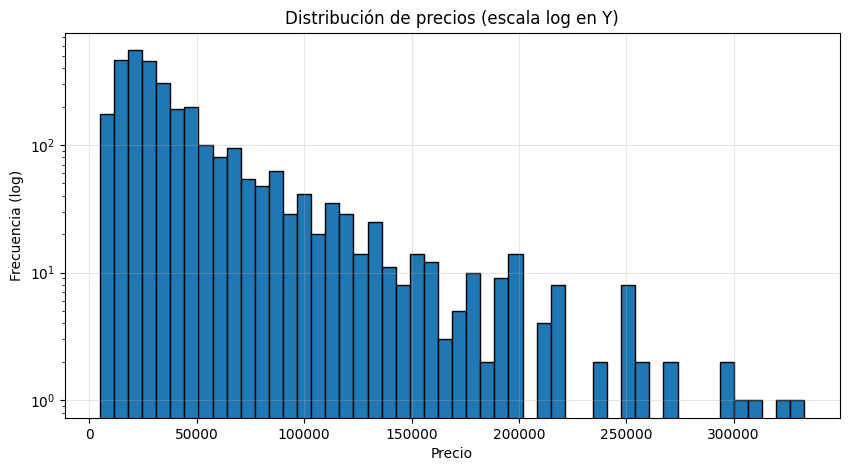

In [31]:
plt.figure(figsize=(10, 5))
plt.hist(df['precio'], bins=50, log=True, edgecolor='black')
plt.title('Distribución de precios (escala log en Y)')
plt.xlabel('Precio')
plt.ylabel('Frecuencia (log)')
plt.grid(True, alpha=0.3)
plt.show()

### **8. Scatter plot Precio vs m² construido (con outliers)**

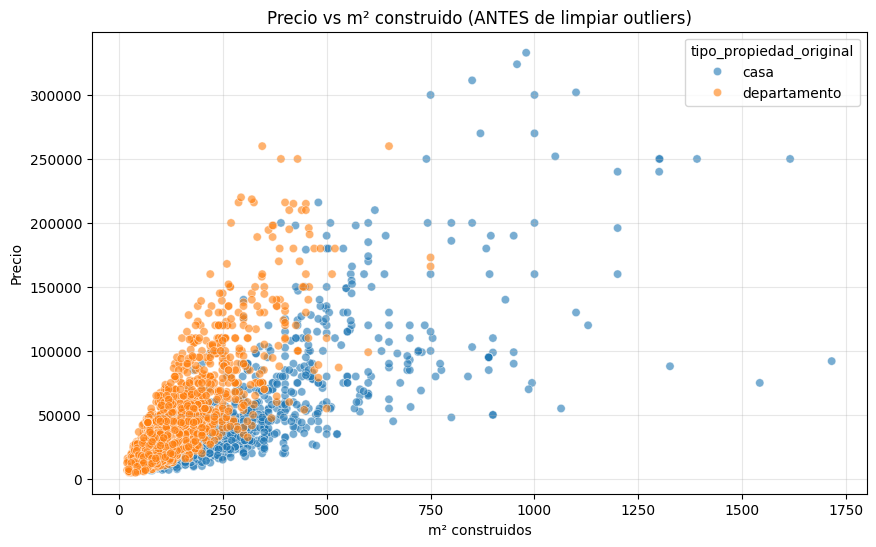

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='m2_construido', y='precio', hue='tipo_propiedad_original', alpha=0.6)
plt.title('Precio vs m² construido (ANTES de limpiar outliers)')
plt.xlabel('m² construidos')
plt.ylabel('Precio')
plt.grid(True, alpha=0.3)
plt.show()

### **9. Boxplots para identificar outliers visualmente**

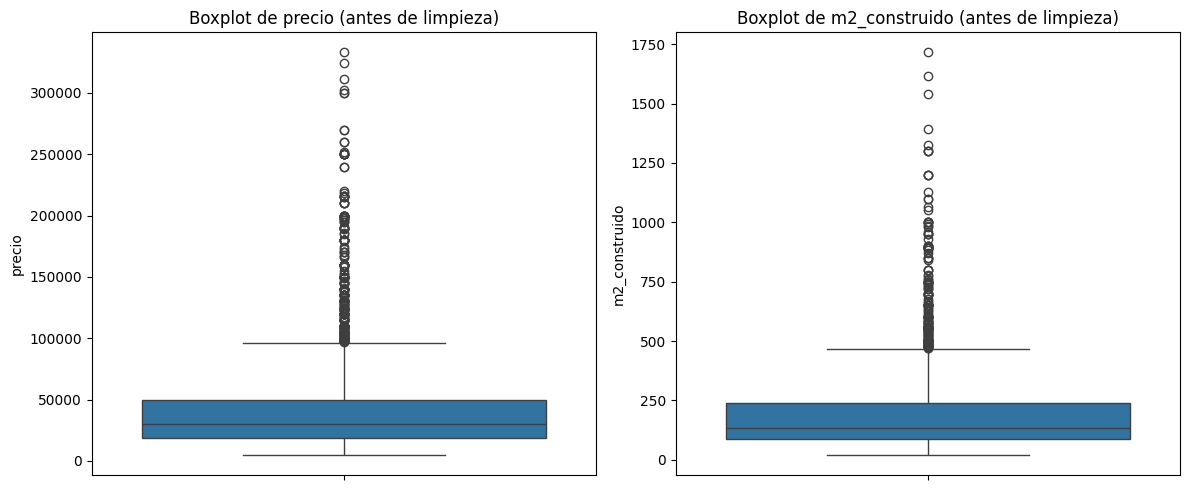

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, y='precio', ax=axes[0])
axes[0].set_title('Boxplot de precio (antes de limpieza)')
sns.boxplot(data=df, y='m2_construido', ax=axes[1])
axes[1].set_title('Boxplot de m2_construido (antes de limpieza)')
plt.tight_layout()
plt.show()

### **10. Correlaciones de las variables numéricas con el precio**

In [34]:
num_cols = df.select_dtypes(include=np.number).columns
corr_precio = df[num_cols].corr()['precio'].sort_values(ascending=False)
print("\n--- Correlaciones con el precio (top 15) ---")
print(corr_precio.head(15))



--- Correlaciones con el precio (top 15) ---
precio                         1.000000
m2_construido                  0.701829
banos                          0.518340
amen_Cuartos de servicio       0.453915
estacionamientos               0.443172
medios_banos                   0.402051
m2_terreno                     0.243155
antiguedad                     0.139466
longitud                       0.089954
amen_Alberca                   0.083163
amen_Elevador                  0.051294
amen_Cocina integral           0.024023
amen_Amueblado                 0.004071
tipo_propiedad_departamento   -0.096064
latitud                       -0.100038
Name: precio, dtype: float64


### **11. Matriz de correlación (mapa de calor)**

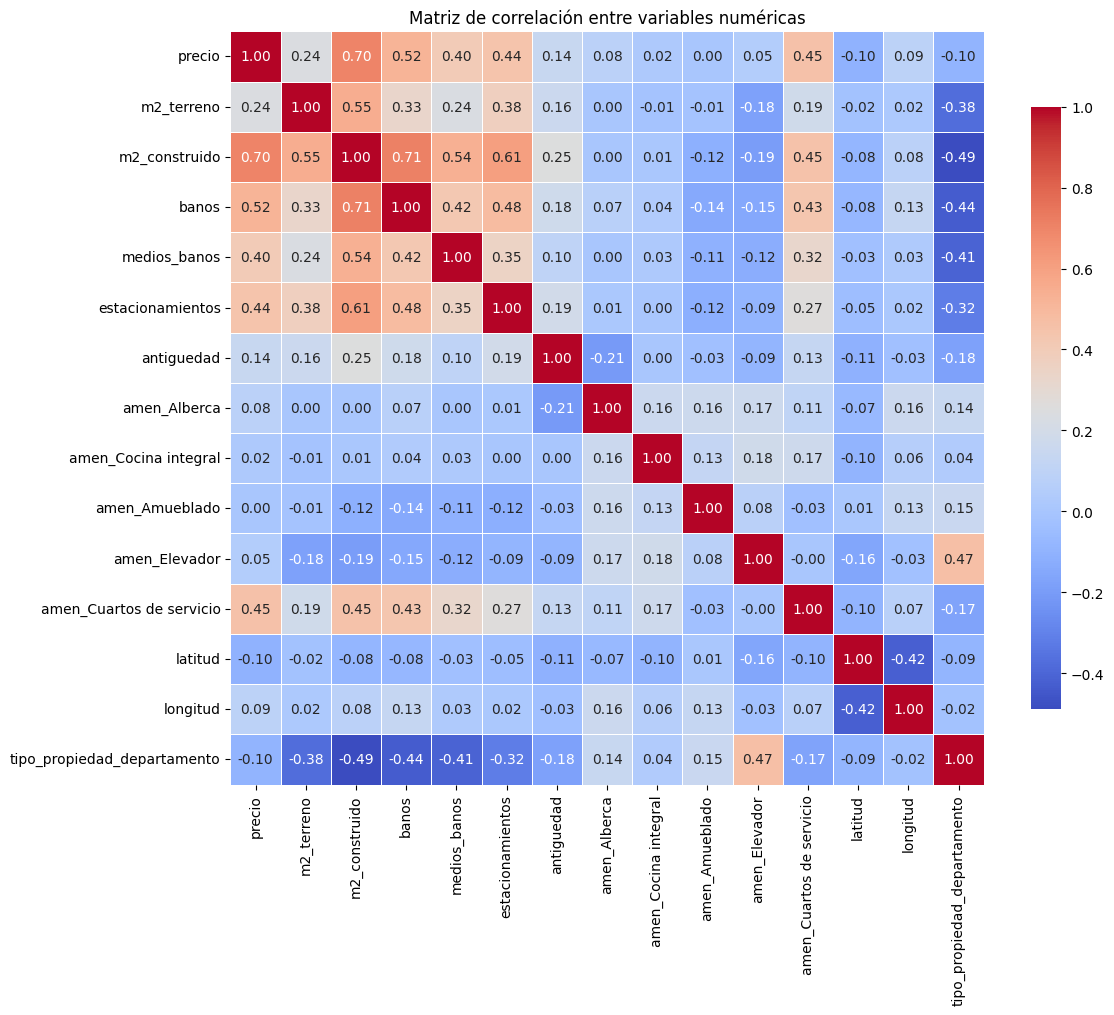

In [35]:
plt.figure(figsize=(12, 10))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

### **12. Heatmap solo con las 10 variables más correlacionadas con precio.**

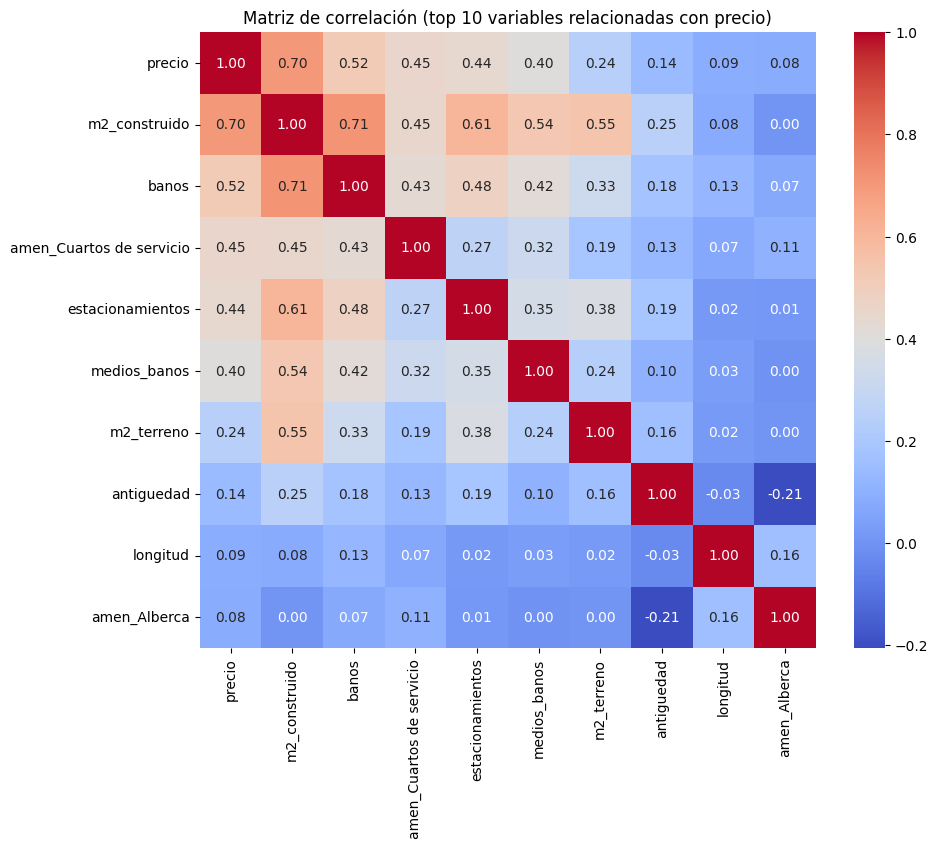

In [36]:
top_corr = corr_precio.head(10).index
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de correlación (top 10 variables relacionadas con precio)')
plt.show()

### **13. Limpieza de Outliers.**
Para cada tipo de propiedad (casa / departamento):

- Elimina precios fuera de los percentiles 0.5 y 99.5
- Elimina m2_construido fuera de [15, 2000]
- Elimina registros con precio por m² fuera de percentiles 1 y 99

In [37]:
def limpiar_outliers(grupo):
    # Precio
    p_low = grupo['precio'].quantile(0.005) #0.005
    p_high = grupo['precio'].quantile(0.995) # 0.995
    mask = (grupo['precio'] >= p_low) & (grupo['precio'] <= p_high)
    
    # Metros cuadrados
    mask &= (grupo['m2_construido'] >= 15) & (grupo['m2_construido'] <= 2000)
    
    # Precio por m²
    grupo['precio_m2'] = grupo['precio'] / grupo['m2_construido']
    m2_low = grupo['precio_m2'].quantile(0.01) # 0.01
    m2_high = grupo['precio_m2'].quantile(0.99) # 0.99
    mask &= (grupo['precio_m2'] >= m2_low) & (grupo['precio_m2'] <= m2_high)
    
    return grupo[mask]

### **14. Aplicación de Limpieza.**

In [38]:
df_clean = df.groupby('tipo_propiedad_original', group_keys=False).apply(limpiar_outliers)
df_clean.drop(columns='precio_m2', inplace=True, errors='ignore')

print(f"\nRegistros después de limpiar outliers: {len(df_clean)}")
print(f"Registros eliminados: {len(df) - len(df_clean)}")


Registros después de limpiar outliers: 3010
Registros eliminados: 87


C:\Users\Dell\AppData\Local\Temp\ipykernel_23764\3057747843.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df.groupby('tipo_propiedad_original', group_keys=False).apply(limpiar_outliers)


### **15. Verificar distribución por tipo después de limpieza**

In [39]:
print("\n--- Distribución por tipo después de limpieza ---")
print(df_clean['tipo_propiedad_original'].value_counts())


--- Distribución por tipo después de limpieza ---
tipo_propiedad_original
departamento    1989
casa            1021
Name: count, dtype: int64


### **16. Estadísticos después de la limpieza**

In [40]:
print("\n--- Estadísticos del precio (después de limpieza) ---")
print(df_clean['precio'].describe())

print("\n--- Estadísticos de m2_construido (después de limpieza) ---")
print(df_clean['m2_construido'].describe())


--- Estadísticos del precio (después de limpieza) ---
count      3010.000000
mean      41959.615947
std       36503.201640
min        6000.000000
25%       19000.000000
50%       29800.000000
75%       49800.000000
max      270000.000000
Name: precio, dtype: float64

--- Estadísticos de m2_construido (después de limpieza) ---
count    3010.000000
mean      188.626578
std       162.543443
min        20.000000
25%        86.250000
50%       135.000000
75%       236.000000
max      1615.000000
Name: m2_construido, dtype: float64


### **16.b. Estadísticos por tipo de propiedad**

In [43]:
print("\n--- Estadísticos de precio por tipo (después de limpieza)---")
print(df_clean.groupby('tipo_propiedad_original')['precio'].describe())


print("\n--- Estadísticos de m2_construidos por tipo (después de limpieza)---")
print(df_clean.groupby('tipo_propiedad_original')['m2_construido'].describe())


--- Estadísticos de precio por tipo (después de limpieza)---
                          count          mean           std     min      25%  \
tipo_propiedad_original                                                        
casa                     1021.0  46702.099902  43730.638757  7500.0  19000.0   
departamento             1989.0  39525.188537  31908.415935  6000.0  19000.0   

                             50%      75%       max  
tipo_propiedad_original                              
casa                     30000.0  56200.0  270000.0  
departamento             29000.0  47000.0  210000.0  

--- Estadísticos de m2_construidos por tipo (después de limpieza)---
                          count        mean         std   min    25%    50%  \
tipo_propiedad_original                                                       
casa                     1021.0  301.384917  210.691168  41.0  160.0  247.0   
departamento             1989.0  130.745098   85.624666  20.0   75.0  104.0   

              

### **17. Histograma de precios limpios**

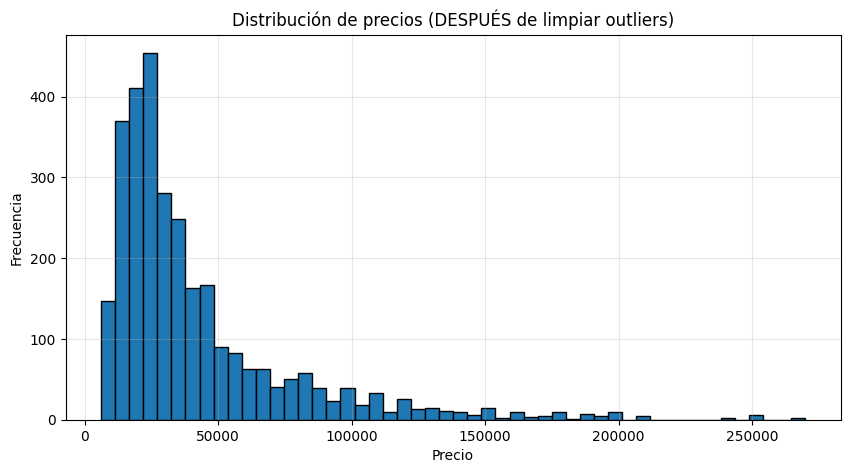

In [44]:
plt.figure(figsize=(10, 5))
plt.hist(df_clean['precio'], bins=50, edgecolor='black')
plt.title('Distribución de precios (DESPUÉS de limpiar outliers)')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.show()

### **18. Scatter plot sin outliers**

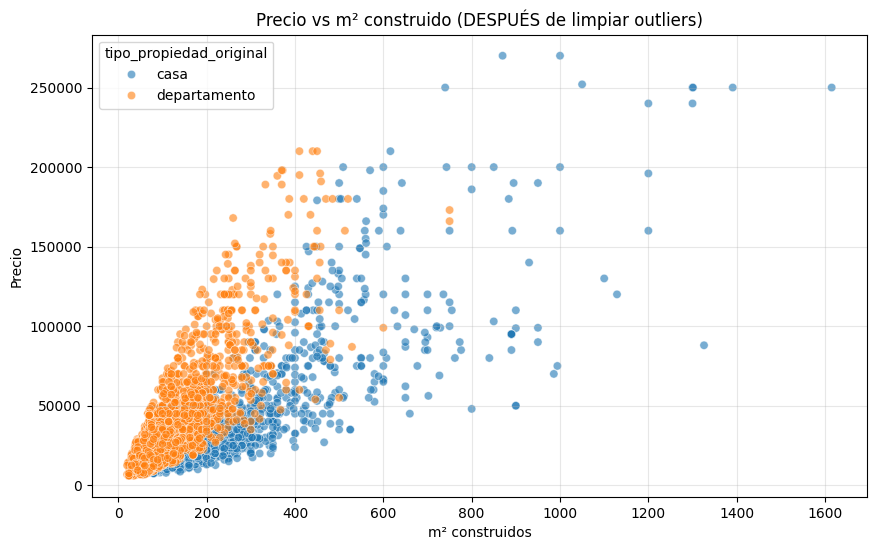

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='m2_construido', y='precio', hue='tipo_propiedad_original', alpha=0.6)
plt.title('Precio vs m² construido (DESPUÉS de limpiar outliers)')
plt.xlabel('m² construidos')
plt.ylabel('Precio')
plt.grid(True, alpha=0.3)
plt.show()

### **19. Boxplots despues de la limpieza.**

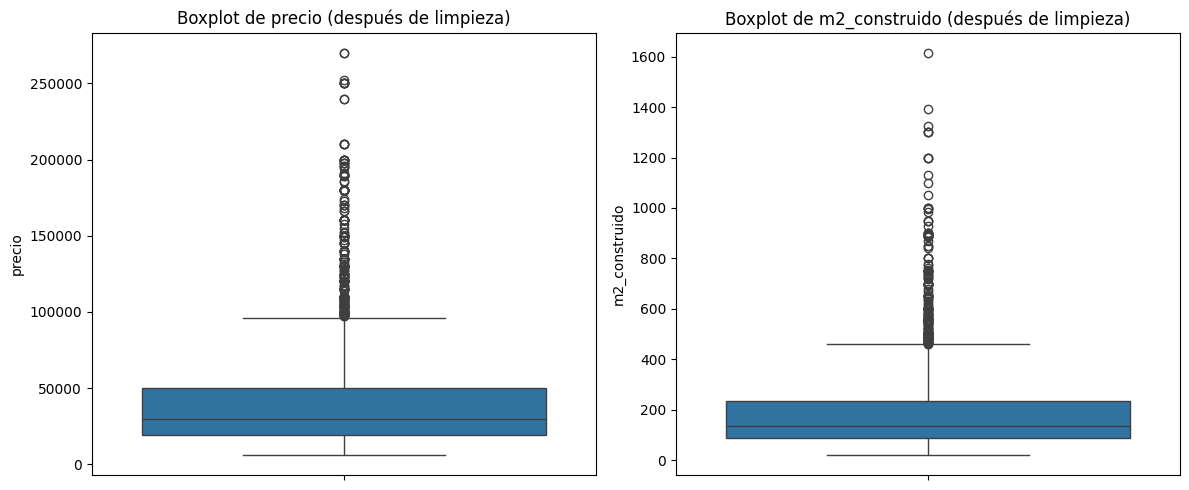

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_clean, y='precio', ax=axes[0])
axes[0].set_title('Boxplot de precio (después de limpieza)')
sns.boxplot(data=df_clean, y='m2_construido', ax=axes[1])
axes[1].set_title('Boxplot de m2_construido (después de limpieza)')
plt.tight_layout()
plt.show()

### **19.b. Boxplots por tipo de propiedad (después de limpieza)**

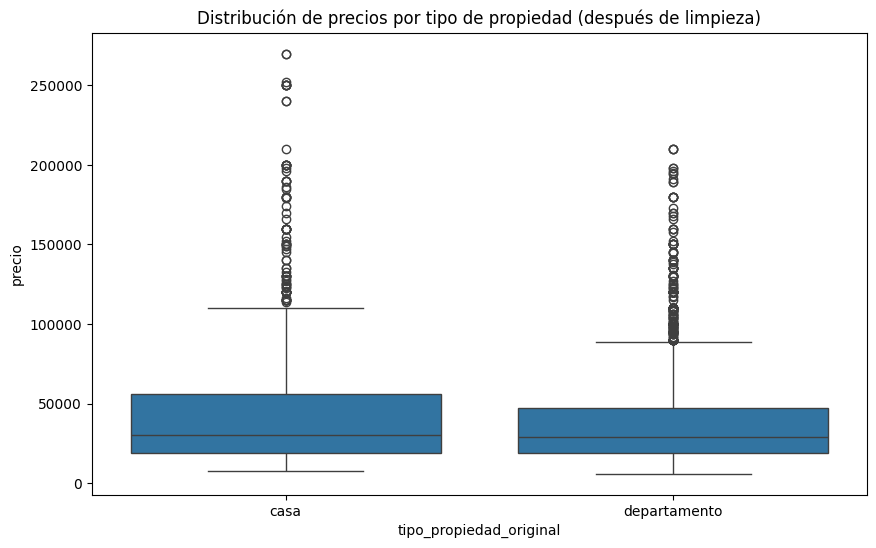

In [47]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='tipo_propiedad_original', y='precio')
plt.title('Distribución de precios por tipo de propiedad (después de limpieza)')
plt.show()

### **20. GUARDAR DATASET LIMPIO**

In [117]:
df_clean.to_csv('rent_features_sin_outliers.csv', index=False, encoding='utf-8')
print("\nDataset limpio guardado como 'rent_features_sin_outliers.csv'")


Dataset limpio guardado como 'rent_features_sin_outliers.csv'
